In [2]:
#Import dependencies
import os
import pandas as pd
import numpy as np
import numpy_financial as npf
import seaborn as sns

# Util function
from scripts.gep_rerun import *

from scripts.gep_plots import *
pd.options.mode.chained_assignment = None
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
file=os.getcwd()+ '/ng-3-scenarios-results/ng-3-2_0_0_0_1_0.csv'

# Run setup
sub_data = check_setup(file)

In [13]:
## (litre/year * $/litre) => $/year spent on diesel
sub_data["DieselCost"] = sub_data["MinOverallDieselCon2030"] * sub_data["MGDieselFuelCost2030"]
sub_data[sub_data.MinimumOverall2030 != "MG_Wind_Hybrid2030"]

,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,Generation_Capex2025,MGDieselFuelCost2030,...,PVHybridDieselConsumption2030,PVHybridGenLCOE2030,MG_Hydro2030,MinimumOverall2030,MinimumOverallLCOE2030,Generation_Capex2030,MinimumOverallGenLCOE2030,MinOverallDieselCon2030,MinimumOverallGenLCOE2030_VOM,DieselCost
0,0.026001,11.828125,10.164062,95767,Gombe,153.125,43240.434,4,33196.297,0.699733,...,116.827225,0.255552,0.956378,MG_PV_Hybrid2030,0.847656,2627.0627,0.255552,116.827225,0.253552,81.747900
1,0.026993,8.203125,5.636719,673350,Cross River,136.875,39611.340,4,0.000,0.680818,...,1035.482800,0.262599,99.000000,MG_PV_Hybrid2030,0.327637,57387.1300,0.262599,1035.482800,0.260599,704.975122
2,0.271973,8.664062,5.105469,512742,Cross River,1040.000,293762.800,4,448393.940,0.710680,...,233.983440,0.283328,99.000000,MG_PV_Hybrid2030,0.406982,23895.5200,0.283328,233.983440,0.281328,166.287351
3,0.062988,13.773438,12.132812,542105,Borno,638.000,180229.030,4,260132.610,0.704377,...,641.089840,0.253792,99.000000,MG_PV_Hybrid2030,0.426758,9113.2720,0.253792,641.089840,0.251792,451.568746
4,0.065979,13.765625,12.132812,542104,Borno,326.000,92092.650,4,132921.440,0.703716,...,338.946780,0.253792,99.000000,MG_PV_Hybrid2030,0.567383,4818.2230,0.253792,338.946780,0.251792,238.522123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1549,0.026993,8.242188,5.269531,292049,Cross River,191.625,50089.176,3,38454.176,0.891876,...,27.180275,0.254848,1.197039,MG_PV_Hybrid2030,0.783691,3457.4343,0.254848,27.180275,0.252848,24.241423
1550,0.062988,9.828125,12.984375,555354,Yobe,380.750,99527.375,3,160231.500,0.943680,...,42.536602,0.255288,99.000000,MG_PV_Hybrid2030,0.550293,7645.0845,0.255288,42.536602,0.253288,40.140925
1551,0.040985,6.718750,4.574219,676478,Bayelsa,1201.000,313889.120,3,523985.970,0.893867,...,128.718000,0.280333,99.000000,MG_PV_Hybrid2030,0.386475,25812.6390,0.280333,128.718000,0.278333,115.056729
1552,0.026993,7.011719,4.410156,674015,Rivers,873.000,246640.250,4,376466.940,0.701180,...,197.296770,0.283328,99.000000,MG_PV_Hybrid2030,0.411133,20148.8980,0.283328,197.296770,0.281328,138.340498


In [14]:
total_MG_investment = (sub_data.Generation_Capex2030.sum()+ sub_data.Generation_Capex2025.sum())/1000000 
total_MG_investment

470.21991491759997

In [15]:
print(f'total_MG_investment_2025: {sub_data.Generation_Capex2025.sum()/1000000}')
print(f'total_MG_investment_2030: {sub_data.Generation_Capex2030.sum()/1000000}')

total_MG_investment_2025: 446.536138543
total_MG_investment_2030: 23.6837763746


In [18]:
path=os.getcwd()+ '/results/scenarios'

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        df = df[df.Ft_PerTonRes > 0].reset_index()
        
        if scenario == 'ng-3-0_0_0_0_1_0-results':
            scenario = 'BSCU'
        elif scenario == 'ng-3-0_0_0_1_1_0-results':
            scenario = 'BSCU-L'
        elif scenario == 'ng-3-0_1_0_0_1_0-results':
            scenario = 'Baseline'
        elif scenario == 'ng-3-0_1_0_1_1_0-results':
            scenario = 'Baseline-L'
        elif scenario == 'ng-3-2_0_0_0_1_0-results':
            scenario = 'HDSCU'
        elif scenario == 'ng-3-2_0_0_1_1_0-results':
            scenario = 'HDSCU-L'
        
        print(scenario)
        
        print(f'total_MG_investment_2025: {df.Generation_Capex2025.sum()/1000000}')
        print(f'total_MG_investment_2030: {df.Generation_Capex2030.sum()/1000000}')

BSCU
total_MG_investment_2025: 0.0
total_MG_investment_2030: 1.189359768
BSCU-L
total_MG_investment_2025: 0.0
total_MG_investment_2030: 0.0
Baseline
total_MG_investment_2025: 0.0
total_MG_investment_2030: 0.082442032
Baseline-L
total_MG_investment_2025: 0.0
total_MG_investment_2030: 0.0
HDSCU
total_MG_investment_2025: 425.90578894
total_MG_investment_2030: 21.505301089299998
HDSCU-L
total_MG_investment_2025: 1.14273469
total_MG_investment_2030: 0.09995209199999999


<AxesSubplot:xlabel='Ft_PerTonRes', ylabel='Count'>

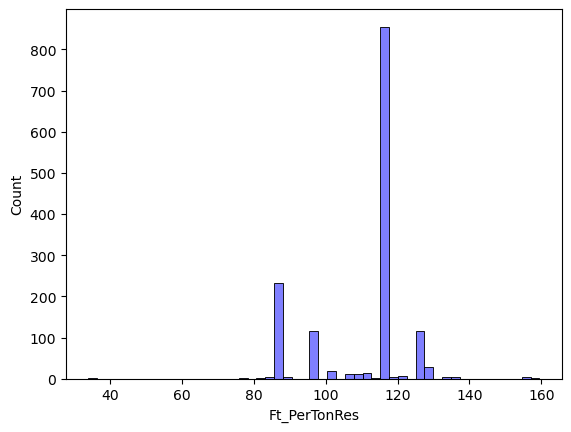

In [13]:
## checking distribution of feedstock funds under high demand HDSCU

file=os.getcwd()+ '/results/scenarios/ng-3-2_0_0_0_1_0-results.csv'
df = pd.read_csv(file)
df = df[df.Ft_PerTonRes > 0]
sns.histplot(data=df, x = 'Ft_PerTonRes', color ='blue',  alpha=0.5, label='Top crop')



## Check in mini-hydro LCOE vs least cost LCOE

In [3]:
scenario_file=os.getcwd()+ '/ng-3-scenarios-results/ng-3-2_0_0_0_1_0.csv'

In [4]:
fields =["GridCellArea","Admin1","Tier","X_deg","Y_deg","id","Pop2030","TotalEnergyPerCell","MinimumOverall2030","MinimumOverallLCOE2030",              "WindHybridGenLCOE2030", "PVHybridGenLCOE2030", "MG_Hydro2030", "Generation_Capex2030", "Generation_Capex2025",
         "MGDieselFuelCost2030","WindHybridDieselConsumption2030", "PVHybridDieselConsumption2030"]

data_types_conversion_numeric = {
                                "GridCellArea": np.float16,
                                "X_deg": np.float16,
                                "Y_deg": np.float16,
                                "Pop2030": np.float16,
                                "MinimumOverallLCOE2030": np.float16,
                                "Tier": np.int16,
                                "Admin1": "category",
                                "MinimumOverall2030": "category"
                                }

sub_data = pd.read_csv(scenario_file, dtype=data_types_conversion_numeric, skipinitialspace=True, usecols=fields)

# Drop non mini-grids
sub_data = sub_data.drop(sub_data[(sub_data.MinimumOverall2030 == 'Grid2030') | (sub_data.MinimumOverall2030 == 'SA_PV2030')].index)

In [16]:
sub_data = sub_data[(sub_data.MinimumOverall2030 == 'MG_Hydro2030')]

In [49]:
sub_data[(sub_data.MinimumOverallLCOE2030 < 0.28)].describe()

,GridCellArea,X_deg,Y_deg,id,Pop2030,TotalEnergyPerCell,Tier,Generation_Capex2025,MGDieselFuelCost2030,WindHybridDieselConsumption2030,WindHybridGenLCOE2030,PVHybridDieselConsumption2030,PVHybridGenLCOE2030,MG_Hydro2030,MinimumOverallLCOE2030,Generation_Capex2030
count,33.000000,33.000000,33.000000,33.000000,33.000,3.300000e+01,33.000000,3.300000e+01,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,0.080139,10.804688,9.906250,450563.606061,517.500,1.482384e+05,3.939394,1.338513e+05,0.712039,5690.664924,18.646822,2474.510498,0.255163,0.217218,0.217163,33677.131758
std,0.158325,3.541016,2.376953,207257.034325,inf,4.191853e+05,0.242306,6.016969e+05,0.050037,3966.319325,38.466700,1995.202502,0.008138,0.032845,0.032837,14720.123257
min,0.009003,3.292969,5.558594,4586.000000,83.750,1.720412e+04,3.000000,0.000000e+00,0.641315,0.000000,0.442826,229.978870,0.243503,0.133943,0.133911,7047.671000
25%,0.026001,7.996094,7.753906,434833.000000,128.125,3.536310e+04,4.000000,0.000000e+00,0.660907,3196.396700,0.912394,1012.652830,0.253745,0.200233,0.200195,27569.305000
50%,0.035004,13.062500,11.109375,503385.000000,142.125,3.966666e+04,4.000000,0.000000e+00,0.720055,6067.101000,0.931978,1969.273800,0.253792,0.216099,0.216064,30647.951000
75%,0.062012,13.507812,11.273438,599754.000000,182.375,5.149727e+04,4.000000,0.000000e+00,0.737989,8065.442400,0.951563,3406.335000,0.257481,0.239781,0.239746,37900.598000
max,0.917969,14.195312,12.820312,712133.000000,8192.000,2.381038e+06,4.000000,3.436659e+06,0.818204,15582.029000,99.000000,8186.425300,0.285665,0.278621,0.278564,79700.500000


In [ ]:
sub_data.Pop2030.head(50)

In [40]:
scenario_res=os.getcwd()+ '/results/scenarios/ng-3-2_0_0_0_1_0-results.csv'
sub_data2 = pd.read_csv(scenario_res)

In [41]:
sub_data2 = sub_data2[(sub_data2.Ft_PerTonRes > 0)].Pop2030.describe()

In [42]:
sub_data2

count    1441.000000
mean      734.921176
std       681.420057
min        15.914000
25%       359.500000
50%       517.500000
75%       854.000000
max      7416.000000
Name: Pop2030, dtype: float64